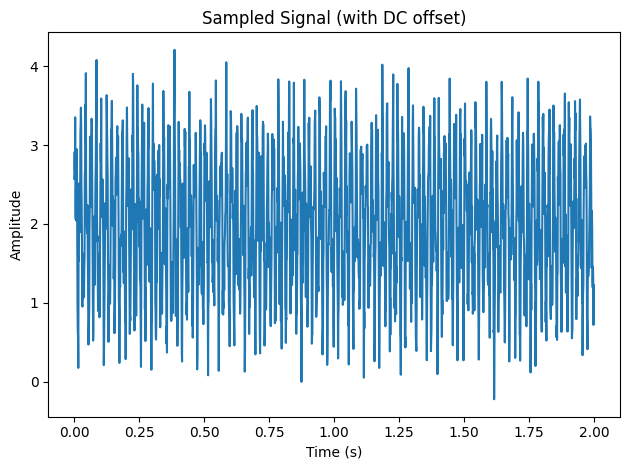

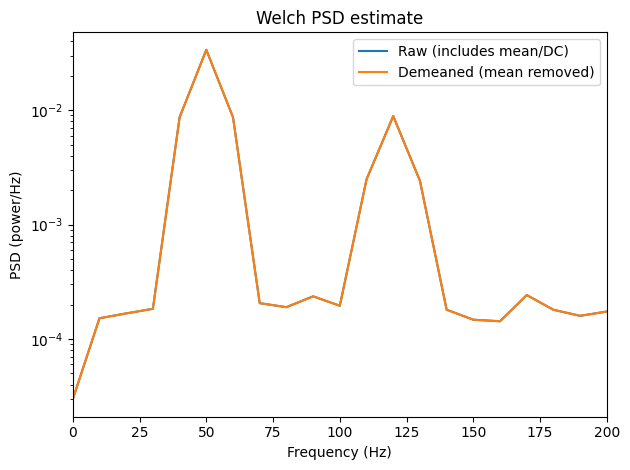

Variance of demeaned signal: 0.7210754559663778
Integral of demeaned PSD:    0.7250342998088846


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# --- 1) Create a simple sampled signal: two sinusoids + noise + a nonzero mean (DC offset)
fs = 1000  # sampling rate in Hz
T = 2.0    # seconds
t = np.arange(0, T, 1/fs)

x = (
    1.0 * np.sin(2*np.pi*50*t) +      # 50 Hz tone
    0.5 * np.sin(2*np.pi*120*t) +     # 120 Hz tone
    0.3 * np.random.randn(len(t)) +   # noise
    2.0                                # DC offset (nonzero mean)
)

plt.figure()
plt.plot(t, x)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sampled Signal (with DC offset)")
plt.tight_layout()
plt.show()

# --- 2) PSD estimate of the raw signal (includes DC component)
f_raw, Pxx_raw = welch(x, fs=fs, nperseg=100)

# --- 3) PSD estimate after de-meaning (covariance-based view; removes DC spike)
x_demeaned = x - np.mean(x)
f_dm, Pxx_dm = welch(x_demeaned, fs=fs, nperseg=252)

# --- 4) Plot
plt.figure()
plt.semilogy(f_raw, Pxx_raw, label="Raw (includes mean/DC)")
plt.semilogy(f_dm, Pxx_dm, label="Demeaned (mean removed)")
plt.xlim(0, 200)  # focus on low frequencies
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (power/Hz)")
plt.title("Welch PSD estimate")
plt.legend()
plt.tight_layout()
plt.show()

# --- 5) Quick numeric check: variance equals integral of PSD (approximately)
# For the demeaned signal, total power ~= variance.
df = f_dm[1] - f_dm[0]
power_from_psd = np.sum(Pxx_dm) * df
print("Variance of demeaned signal:", np.var(x_demeaned))
print("Integral of demeaned PSD:   ", power_from_psd)
